# Environment Check

Run **every cell from the top**, in order.

- If a cell fails, note the **check number** printed in the cell and the **full error message**, and send both to the TA.
- If all cells run, **save the notebook** (Ctrl+S / Cmd+S) and submit **this `.ipynb` file itself**. Do not submit a screenshot.

Make sure you launched JupyterLab from the `climstat` environment — the prompt should have shown `(climstat)` before you ran `jupyter-lab`. The kernel will simply say `Python 3 (ipykernel)`; that is correct.

## Check 1 — Package versions

In [1]:
import sys
import numpy, scipy, pandas, xarray, matplotlib, cartopy, statsmodels

print("check 1")
print("python      ", sys.version.split()[0])
for m in (numpy, scipy, pandas, xarray, matplotlib, cartopy, statsmodels):
    print(f"{m.__name__:12s}", m.__version__)

check 1
python       3.12.14
numpy        2.5.2
scipy        1.18.0
pandas       3.0.5
xarray       2026.7.0
matplotlib   3.10.9
cartopy      0.25.0
statsmodels  0.14.6


## Check 2 — Plotting

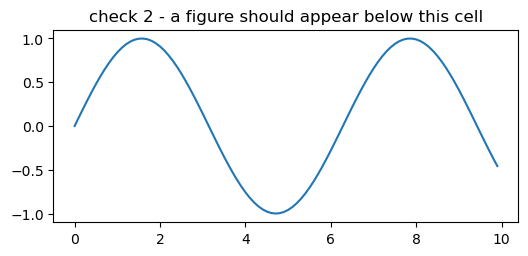

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 10, 0.1)
plt.figure(figsize=(6, 2.5))
plt.plot(x, np.sin(x))
plt.title("check 2 - a figure should appear below this cell")
plt.show()

## Check 3 — Map with coastlines

This needs cartopy's map data. If the map appears but has **no coastlines**,
your environment is incomplete — tell the TA.

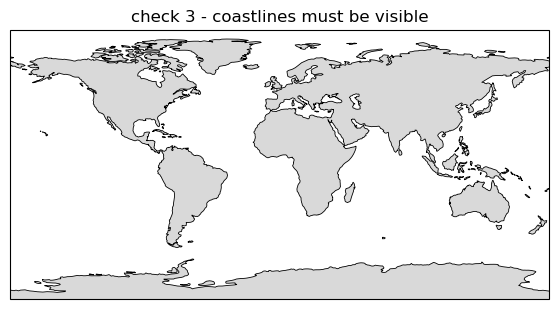

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(7, 3.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.set_global()
plt.title("check 3 - coastlines must be visible")
plt.show()

## Check 4 — Reading a NetCDF file

`data/sample_sst.nc` is a short excerpt of the NOAA OISST monthly dataset,
included in this repository.

In [4]:
import xarray as xr

ds = xr.open_dataset("data/sample_sst.nc")
print("check 4")
print(ds)

check 4
<xarray.Dataset> Size: 6MB
Dimensions:    (time: 24, bnds: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) datetime64[ns] 192B 1981-12-01 1982-01-01 ... 1983-11-01
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 384B ...
    sst        (time, lat, lon) float32 6MB ...
Attributes:
    CDI:            Climate Data Interface version 2.0.4 (https://mpimet.mpg....
    Conventions:    CF-1.0
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    title:          NOAA Optimum Interpolation (OI) SST V2
    history:        Wed Aug 26 13:58:03 2026: cdo seltimestep,1/24 sst.mnmean...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    References:     https:

## Check 5 — A time series at one grid point

This is the code we will use in class. It picks the grid cell nearest to
35N, 130E (the East Sea) and plots its time series.

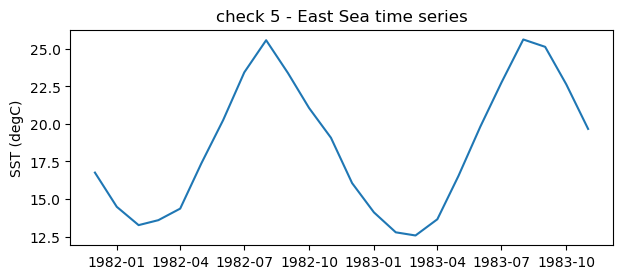

check 5 ok


In [5]:
sst = ds.sst
grid = sst.sel(lat=[35], lon=[130], method="nearest")[:, 0, 0]

plt.figure(figsize=(7, 2.8))
plt.plot(grid.time.values, grid)
plt.ylabel("SST (degC)")
plt.title("check 5 - East Sea time series")
plt.show()

print("check 5 ok")

## Check 6 — EOF analysis

In [6]:
from eofs.xarray import Eof

anom = sst - sst.mean(dim="time")
solver = Eof(anom)
var_frac = solver.varianceFraction(neigs=3)

print("check 6")
print("explained variance of the first 3 modes:", var_frac.values.round(3))

check 6
explained variance of the first 3 modes: [0.881 0.036 0.028]


## Check 7 — Wavelet functions

`waveletFunctions.py` is **not** an installable package — it is a plain Python
file that must sit in this folder. If this cell fails, the file is missing.

In [7]:
try:
    from waveletFunctions import wavelet
    print("check 7 ok")
except ImportError as e:
    print("check 7 FAILED:", e)
    print("waveletFunctions.py must be in the same folder as this notebook.")

check 7 ok


## Check 8 — Remaining imports

In [8]:
import math, platform, getpass, socket
from datetime import datetime
import pandas as pd
from scipy import stats
from scipy.signal import detrend
from statsmodels.tsa.stattools import acf
from matplotlib.colors import BoundaryNorm

print("check 8 ok")
print()
print("=" * 58)
print(" All checks passed. Your environment is ready.")
print("=" * 58)
print(f" run at   : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" user     : {getpass.getuser()}")
print(f" machine  : {socket.gethostname()}")
print(f" system   : {platform.system()} {platform.release()} ({platform.machine()})")
print(f" python   : {sys.executable}")
print("=" * 58)
print(" Save this notebook (Ctrl+S) and submit the .ipynb file.")

check 8 ok

 All checks passed. Your environment is ready.
 run at   : 2026-08-26 18:24:57
 user     : jsp
 machine  : ThinkPad-X1-Carbon-Gen-11
 system   : Linux 6.8.0-136-generic (x86_64)
 python   : /home/jsp/anaconda3/envs/climstat/bin/python
 Save this notebook (Ctrl+S) and submit the .ipynb file.
